This notebook aggregates the individual taxi trips into hourly taxi demand per pickup location.

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import joblib
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

In [2]:
data = pl.read_parquet("../data/02/02_merged_data.parquet", columns=["trip_start", "pickup_community_area", "pickup_census_tract", 'bin_1h', 'bin_4h', 'bin_1d', 'date']).rename({"trip_start": "bin_15m", 'pickup_community_area': 'community_area', 'pickup_census_tract': 'census_tract'})
display(data.shape)
display(data.head(3))

(13505728, 7)

bin_15m,community_area,census_tract,bin_1h,bin_4h,bin_1d,date
"datetime[ms, America/Chicago]",i64,i64,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",date
2024-01-01 00:30:00 CST,21,null,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01
2024-01-01 00:00:00 CST,8,null,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01
2024-01-01 00:45:00 CST,6,null,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01


# Trip Aggregation
We previously aggregated a lot of data for the temporal spatial analysis. To use this we do the following:
0. Create all buckets for all the datasets
1. Create a list of trips for census tract and community level 
2. Aggregate the lists to census tract/community for the time buckets 1h, 4h and 1d
3. Select the additional data and drop duplicates
4. Merge both datasets
5. Merge POI data
6. Merge Centroid data

We keep in mind, that the census tract includes a lot of missing values, therefore we must drop the missing records first. The result is that we have less than half of the records for the census tract aggregation.

In [3]:
print("Total number of records:", data.shape[0])

Total number of records: 13505728


# 1. Create grid of time and spatial buckets
We create a grid of time buckets and spatial units to ensure that we have a record for every 1h/4h/1d and census tract/community area. If we would aggregate with just a group_by clause, we would end up with no records including trip_count=0.

In [4]:
timeline_1h = pl.datetime_range(
    data['bin_1h'].min(), data['bin_1h'].max(),
    interval='1h', time_zone='America/Chicago', eager=True,
).dt.cast_time_unit('ms')  

all_bins_1h = pl.DataFrame({'bin_1h': timeline_1h}).unique().sort('bin_1h')
all_bins_4h = pl.DataFrame({'bin_4h': timeline_1h.dt.truncate('4h')}).unique().sort('bin_4h')
all_bins_1d = pl.DataFrame({'bin_1d': timeline_1h.dt.truncate('1d')}).unique().sort('bin_1d')

print(f'Complete timeline -> 1h buckets: {all_bins_1h.height:,}  '
      f'4h buckets: {all_bins_4h.height:,}  1d buckets: {all_bins_1d.height:,}')

Complete timeline -> 1h buckets: 20,424  4h buckets: 5,107  1d buckets: 852


In [5]:
census_areas = data.select('census_tract').unique().drop_nulls().sort('census_tract')
print(f'Unique census tracts: {census_areas.height:,}')

community_areas = data.select('community_area').unique().drop_nulls().sort('community_area')
print(f'Unique community areas: {community_areas.height:,}')

Unique census tracts: 473
Unique community areas: 77


In [6]:
census_1h = census_areas.join(all_bins_1h, how='cross').with_columns(pl.col('bin_1h').cast(pl.Date).alias('Date'), pl.col('bin_1h').dt.hour().alias('hour'), pl.col('bin_1h').dt.month().alias('month'))
print(f'Unique census tracts x 1h bins: {census_1h.height:,}')

census_4h = census_areas.join(all_bins_4h, how='cross').with_columns(pl.col('bin_4h').cast(pl.Date).alias('Date'), pl.col('bin_4h').dt.hour().alias('hour'), pl.col('bin_4h').dt.month().alias('month'))
print(f'Unique census tracts x 4h bins: {census_4h.height:,}')

census_1d = census_areas.join(all_bins_1d, how='cross').with_columns(pl.col('bin_1d').cast(pl.Date).alias('Date'), pl.col('bin_1d').dt.hour().alias('hour'), pl.col('bin_1d').dt.month().alias('month'))
print(f'Unique census tracts x 1d bins: {census_1d.height:,}')

community_1h = community_areas.join(all_bins_1h, how='cross').with_columns(pl.col('bin_1h').cast(pl.Date).alias('Date'), pl.col('bin_1h').dt.hour().alias('hour'), pl.col('bin_1h').dt.month().alias('month'))
print(f'Unique community areas x 1h bins: {community_1h.height:,}')

community_4h = community_areas.join(all_bins_4h, how='cross').with_columns(pl.col('bin_4h').cast(pl.Date).alias('Date'), pl.col('bin_4h').dt.hour().alias('hour'), pl.col('bin_4h').dt.month().alias('month'))
print(f'Unique community areas x 4h bins: {community_4h.height:,}')

community_1d = community_areas.join(all_bins_1d, how='cross').with_columns(pl.col('bin_1d').cast(pl.Date).alias('Date'), pl.col('bin_1d').dt.hour().alias('hour'), pl.col('bin_1d').dt.month().alias('month'))
print(f'Unique community areas x 1d bins: {community_1d.height:,}')

Unique census tracts x 1h bins: 9,660,552
Unique census tracts x 4h bins: 2,415,611
Unique census tracts x 1d bins: 402,996
Unique community areas x 1h bins: 1,572,648
Unique community areas x 4h bins: 393,239
Unique community areas x 1d bins: 65,604


In [7]:
display(census_areas.head(3))

census_tract
i64
17031010100
17031010201
17031010202


# 2. Aggregate based on time bucket and spatial unit
Here the values are aggregated based on the buckets. 

> Note: A lot of data is missing the census tract data, so it will end up with less data.

In [8]:
print("Number of missing values in census tracts:", data['census_tract'].null_count())
print("Percentage of missing values in census tracts:", round(data['census_tract'].null_count() / data.shape[0] * 100, 2), "%")


print("Number of missing values in community areas:", data['community_area'].null_count())


print("Number of records with census tract data:", data.filter(pl.col('census_tract').is_not_null()).shape[0])
print("Number of records with community area data:", data.filter(pl.col('community_area').is_not_null()).shape[0])

Number of missing values in census tracts: 7399844
Percentage of missing values in census tracts: 54.79 %
Number of missing values in community areas: 0
Number of records with census tract data: 6105884
Number of records with community area data: 13505728


In [9]:
trips_census_agg_1h = (
    census_1h
    .join(data.group_by(['census_tract', 'bin_1h']).agg(pl.len().alias('trip_count')),
          on=['census_tract', 'bin_1h'], how='left')
    .with_columns(pl.col('trip_count').fill_null(0).cast(pl.UInt32))
    .sort('bin_1h')
)

trips_census_agg_4h = (
    census_4h
    .join(data.group_by(['census_tract', 'bin_4h']).agg(pl.len().alias('trip_count')),
          on=['census_tract', 'bin_4h'], how='left')
    .with_columns(pl.col('trip_count').fill_null(0).cast(pl.UInt32))
    .sort('bin_4h')
)

trips_census_agg_1d = (
    census_1d
    .join(data.group_by(['census_tract', 'bin_1d']).agg(pl.len().alias('trip_count')),
          on=['census_tract', 'bin_1d'], how='left')
    .with_columns(pl.col('trip_count').fill_null(0).cast(pl.UInt32))
    .sort('bin_1d')
)

print("Example of aggregated trips (1h):")
display(trips_census_agg_1h.head(2))

for label, agg in [('1h', trips_census_agg_1h), ('4h', trips_census_agg_4h), ('1d', trips_census_agg_1d)]:
    n_zero = (agg['trip_count'] == 0).sum()
    print(f'Grid ({label}): {agg.height:,} rows (census_tract x bin), '
          f'{n_zero:,} ({n_zero / agg.height:.1%}) buckets with zero trips')

Example of aggregated trips (1h):


census_tract,bin_1h,Date,hour,month,trip_count
i64,"datetime[ms, America/Chicago]",date,i8,i8,u32
17031010100,2024-01-01 00:00:00 CST,2024-01-01,0,1,0
17031010201,2024-01-01 00:00:00 CST,2024-01-01,0,1,0


Grid (1h): 9,660,552 rows (census_tract x bin), 9,272,242 (96.0%) buckets with zero trips
Grid (4h): 2,415,611 rows (census_tract x bin), 2,259,325 (93.5%) buckets with zero trips
Grid (1d): 402,996 rows (census_tract x bin), 349,093 (86.6%) buckets with zero trips


Below you can see distribution plots about the aggregated data. So you can see how frequent it is that a specific count of trips in a census in a 1h/4h/1d bin is.

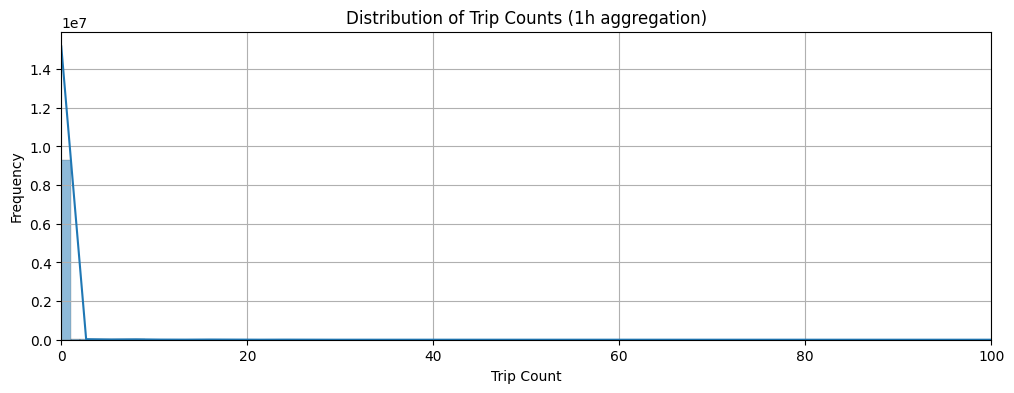

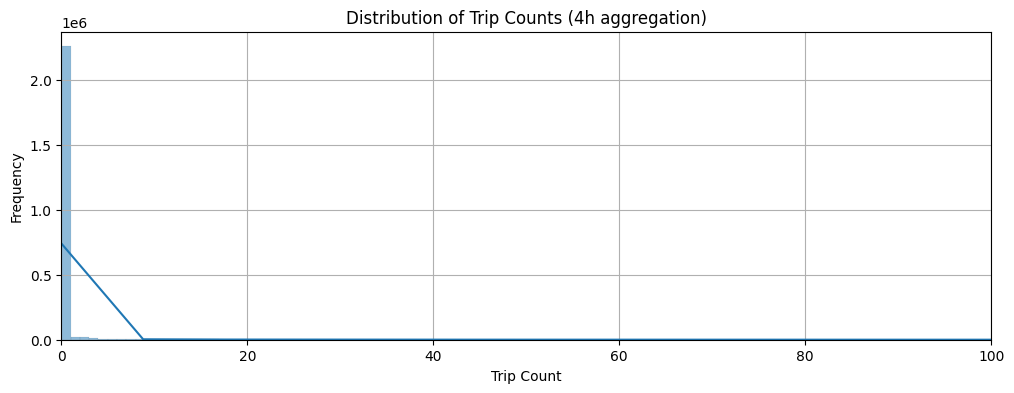

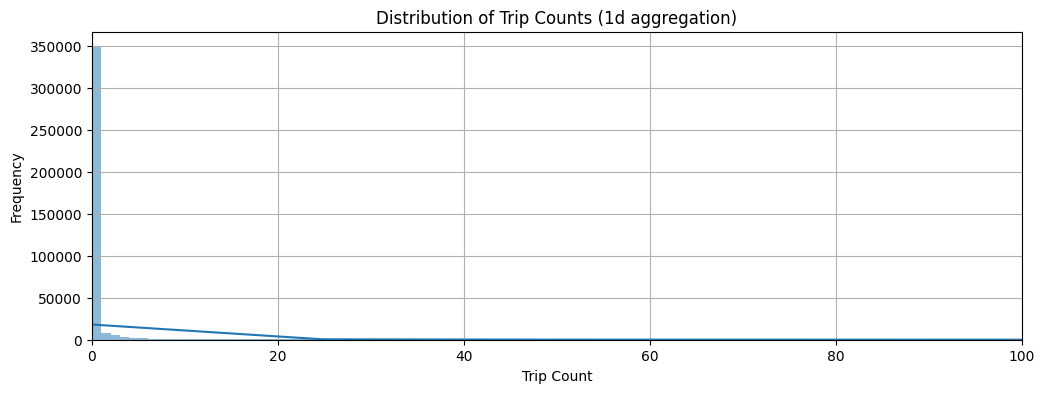

In [10]:
# Distribution plot of trip counts for each aggregation level
for label, agg in [('1h', trips_census_agg_1h), ('4h', trips_census_agg_4h), ('1d', trips_census_agg_1d)]:
    plt.figure(figsize=(12, 4))
    sns.histplot(agg['trip_count'], binwidth=1, kde=True)
    plt.title(f'Distribution of Trip Counts ({label} aggregation)')
    plt.xlabel('Trip Count')
    plt.ylabel('Frequency')
    plt.xlim(0, 100)  # Limit x-axis for better visibility
    plt.grid()
    plt.show()

In [11]:

trips_community_agg_1h = (
    community_1h
    .join(data.group_by(['community_area', 'bin_1h']).agg(pl.len().alias('trip_count')),
          on=['community_area', 'bin_1h'], how='left')
    .with_columns(pl.col('trip_count').fill_null(0).cast(pl.UInt32))
    .sort('bin_1h')
)

trips_community_agg_4h = (
    community_4h
    .join(data.group_by(['community_area', 'bin_4h']).agg(pl.len().alias('trip_count')),
          on=['community_area', 'bin_4h'], how='left')
    .with_columns(pl.col('trip_count').fill_null(0).cast(pl.UInt32))
    .sort('bin_4h')
)

trips_community_agg_1d = (
    community_1d
    .join(data.group_by(['community_area', 'bin_1d']).agg(pl.len().alias('trip_count')),
          on=['community_area', 'bin_1d'], how='left')
    .with_columns(pl.col('trip_count').fill_null(0).cast(pl.UInt32))
    .sort('bin_1d')
)

print("Example of aggregated trips (1h):")
display(trips_community_agg_1h.head(2))

for label, agg in [('1h', trips_community_agg_1h), ('4h', trips_community_agg_4h), ('1d', trips_community_agg_1d)]:
    n_zero = (agg['trip_count'] == 0).sum()
    print(f'Grid ({label}): {agg.height:,} rows (community_area x bin), '
          f'{n_zero:,} ({n_zero / agg.height:.1%}) buckets with zero trips')

Example of aggregated trips (1h):


community_area,bin_1h,Date,hour,month,trip_count
i64,"datetime[ms, America/Chicago]",date,i8,i8,u32
1,2024-01-01 00:00:00 CST,2024-01-01,0,1,1
2,2024-01-01 00:00:00 CST,2024-01-01,0,1,0


Grid (1h): 1,572,648 rows (community_area x bin), 688,049 (43.8%) buckets with zero trips
Grid (4h): 393,239 rows (community_area x bin), 74,433 (18.9%) buckets with zero trips
Grid (1d): 65,604 rows (community_area x bin), 589 (0.9%) buckets with zero trips


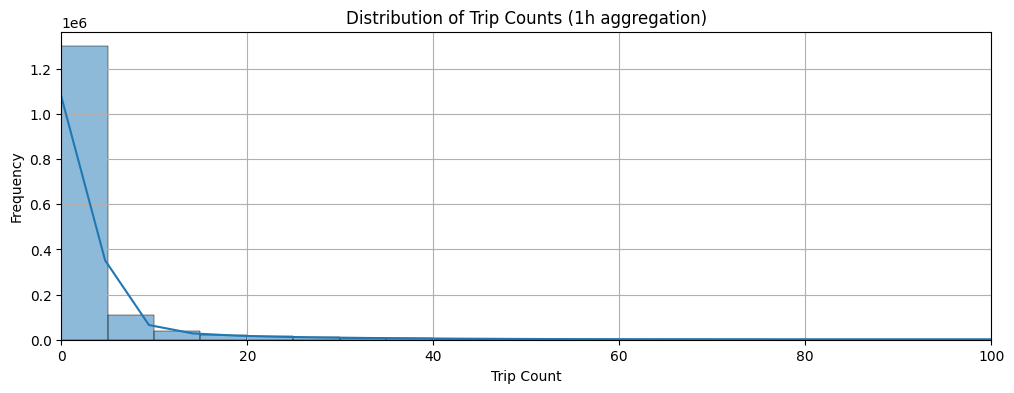

In [ ]:
# Distribution plot of trip counts for each aggregation level
for label, agg in [('1h', trips_community_agg_1h), ('4h', trips_community_agg_4h), ('1d', trips_community_agg_1d)]:
    plt.figure(figsize=(12, 4))
    sns.histplot(agg['trip_count'], binwidth=5, kde=True)
    plt.title(f'Distribution of Trip Counts ({label} aggregation)')
    plt.xlabel('Trip Count')
    plt.ylabel('Frequency')
    plt.xlim(0, 100)  # Limit x-axis for better visibility
    plt.grid()
    plt.show()

# 3. Additional data
We already prepared the additional data in the previous notebook, hence we just import it and merge it to the datasets.

## Holiday Data

In [ ]:
holiday_data = pl.read_parquet("../data/02/02_holiday_data_cleaned.parquet")
trips_community_agg_1h = trips_community_agg_1h.join(holiday_data, left_on='Date', right_on='Date', how='left').drop('Date')
trips_community_agg_4h = trips_community_agg_4h.join(holiday_data, left_on='Date', right_on='Date', how='left').drop('Date')
trips_community_agg_1d = trips_community_agg_1d.join(holiday_data, left_on='Date', right_on='Date', how='left').drop('Date')
trips_census_agg_1h = trips_census_agg_1h.join(holiday_data, left_on='Date', right_on='Date', how='left').drop('Date')
trips_census_agg_4h = trips_census_agg_4h.join(holiday_data, left_on='Date', right_on='Date', how='left').drop('Date')
trips_census_agg_1d = trips_census_agg_1d.join(holiday_data, left_on='Date', right_on='Date', how='left').drop('Date')
display(trips_community_agg_1h.head(3))

## POI

In [ ]:
poi_community = pl.read_csv("../data/02/02_poi_per_community_area.csv")
display(poi_community.head(2))
poi_census = pl.read_csv("../data/02/02_poi_per_census_tract.csv")
display(poi_census.head(2))

In [ ]:
poi_cols = ['healthcare', 'education', 'amenity', 'leisure', 'shops', 'public_services', 'tourism', 'nature']
trips_census_agg_1h = trips_census_agg_1h.join(poi_census, on='census_tract', how='left').with_columns(pl.col(poi_cols).fill_null(0))
trips_census_agg_4h = trips_census_agg_4h.join(poi_census, on='census_tract', how='left').with_columns(pl.col(poi_cols).fill_null(0))
trips_census_agg_1d = trips_census_agg_1d.join(poi_census, on='census_tract', how='left').with_columns(pl.col(poi_cols).fill_null(0))

trips_community_agg_1h = trips_community_agg_1h.join(poi_community, on='community_area', how='left').with_columns(pl.col(poi_cols).fill_null(0))
trips_community_agg_4h = trips_community_agg_4h.join(poi_community, on='community_area', how='left').with_columns(pl.col(poi_cols).fill_null(0))
trips_community_agg_1d = trips_community_agg_1d.join(poi_community, on='community_area', how='left').with_columns(pl.col(poi_cols).fill_null(0))  

In [ ]:
display(trips_census_agg_1h.head(3))

## Centroids

In [ ]:
census_centroids = pl.read_csv("../data/02/02_census_centroids.csv")
display(census_centroids.head(2))
community_centroids = pl.read_csv("../data/02/02_community_area_centroids.csv")
display(community_centroids.head(2))

In [ ]:
trips_census_agg_1h = trips_census_agg_1h.join(census_centroids, on='census_tract', how='left')
trips_census_agg_4h = trips_census_agg_4h.join(census_centroids, on='census_tract', how='left')
trips_census_agg_1d = trips_census_agg_1d.join(census_centroids, on='census_tract', how='left')
trips_community_agg_1d = trips_community_agg_1d.join(community_centroids, on='community_area', how='left')
trips_community_agg_4h = trips_community_agg_4h.join(community_centroids, on='community_area', how='left')
trips_community_agg_1h = trips_community_agg_1h.join(community_centroids, on='community_area', how='left')
display(trips_census_agg_1h.head(3))

## Weather
Weather changes along the day, so we group the records together.

In [ ]:
weather_data = pl.read_parquet("../data/02/02_weather_data_cleaned.parquet")
weather_data_4h = weather_data.group_by('date').agg([
    
    pl.col('temperature_c').mean().alias('temperature_c'),
    pl.col('rain').max().alias('rain'),
    pl.col('snow').max().alias('snow'),
    pl.col('wind').max().alias('wind'),
    pl.col('strong_wind').max().alias('strong_wind'),
    pl.col('strong_rain').mean().alias('strong_rain'),
])

trips_census_agg_1h = trips_census_agg_1h.join(weather_data, left_on='bin_1h', right_on='date', how='left')
trips_census_agg_4h = trips_census_agg_4h.join(weather_data, left_on='bin_4h', right_on='date', how='left')
trips_census_agg_1d = trips_census_agg_1d.join(weather_data, left_on='bin_1d', right_on='date', how='left')
trips_community_agg_1h = trips_community_agg_1h.join(weather_data, left_on='bin_1h', right_on='date', how='left')
trips_community_agg_4h = trips_community_agg_4h.join(weather_data, left_on='bin_4h', right_on='date', how='left')
trips_community_agg_1d = trips_community_agg_1d.join(weather_data, left_on='bin_1d', right_on='date', how='left')
display(trips_community_agg_1h.head(3))

# 4. Additional data generation

In [ ]:
trips_census_agg_1h = trips_census_agg_1h.with_columns(
    (2 * np.pi * pl.col("hour") / 24).sin().alias("hour_sin"),
    (2 * np.pi * pl.col("hour") / 24).cos().alias("hour_cos"),
    (2 * np.pi * pl.col("month") / 12).sin().alias("month_sin"),
    (2 * np.pi * pl.col("month") / 12).cos().alias("month_cos"),
).drop("hour", "month")

trips_census_agg_4h = trips_census_agg_4h.with_columns(
    (2 * np.pi * pl.col("hour") / 24).sin().alias("hour_sin"),
    (2 * np.pi * pl.col("hour") / 24).cos().alias("hour_cos"),
    (2 * np.pi * pl.col("month") / 12).sin().alias("month_sin"),
    (2 * np.pi * pl.col("month") / 12).cos().alias("month_cos"),
).drop("hour", "month")

trips_census_agg_1d = trips_census_agg_1d.with_columns(
    (2 * np.pi * pl.col("hour") / 24).sin().alias("hour_sin"),
    (2 * np.pi * pl.col("hour") / 24).cos().alias("hour_cos"),
    (2 * np.pi * pl.col("month") / 12).sin().alias("month_sin"),
    (2 * np.pi * pl.col("month") / 12).cos().alias("month_cos"),
).drop("hour", "month")

trips_community_agg_1h = trips_community_agg_1h.with_columns(
    (2 * np.pi * pl.col("hour") / 24).sin().alias("hour_sin"),
    (2 * np.pi * pl.col("hour") / 24).cos().alias("hour_cos"),
    (2 * np.pi * pl.col("month") / 12).sin().alias("month_sin"),
    (2 * np.pi * pl.col("month") / 12).cos().alias("month_cos"),
).drop("hour", "month")

trips_community_agg_4h = trips_community_agg_4h.with_columns(
    (2 * np.pi * pl.col("hour") / 24).sin().alias("hour_sin"),
    (2 * np.pi * pl.col("hour") / 24).cos().alias("hour_cos"),
    (2 * np.pi * pl.col("month") / 12).sin().alias("month_sin"),
    (2 * np.pi * pl.col("month") / 12).cos().alias("month_cos"),
).drop("hour", "month")

trips_community_agg_1d = trips_community_agg_1d.with_columns(
    (2 * np.pi * pl.col("hour") / 24).sin().alias("hour_sin"),
    (2 * np.pi * pl.col("hour") / 24).cos().alias("hour_cos"),
    (2 * np.pi * pl.col("month") / 12).sin().alias("month_sin"),
    (2 * np.pi * pl.col("month") / 12).cos().alias("month_cos"),
).drop("hour", "month")


# Select columns and sample 10 rows
display(trips_census_agg_1h.select(["hour_sin", "hour_cos",
               "month_sin", "month_cos"]).sample(n=3, seed=42))

In [ ]:
print("Missing values in merged data example 1h:")
display(trips_census_agg_1h.null_count())

length_census_1h = trips_census_agg_1h.shape[0]
length_census_4h = trips_census_agg_4h.shape[0]
length_census_1d = trips_census_agg_1d.shape[0]

trips_census_agg_1h = trips_census_agg_1h.drop_nulls()
trips_census_agg_4h = trips_census_agg_4h.drop_nulls()
trips_census_agg_1d = trips_census_agg_1d.drop_nulls()

print("Number of records after dropping missing values in merged data 1h:", length_census_1h - trips_census_agg_1h.shape[0])
print("Number of records after dropping missing values in merged data 4h:", length_census_4h - trips_census_agg_4h.shape[0])
print("Number of records after dropping missing values in merged data 1d:", length_census_1d - trips_census_agg_1d.shape[0])

One last null count check.

In [ ]:
for name, df in [
    ("trips_census_merged_1h", trips_census_agg_1h),
    ("trips_census_merged_4h", trips_census_agg_4h),
    ("trips_census_merged_1d", trips_census_agg_1d),
    ("trips_community_merged_1h", trips_community_agg_1h),
    ("trips_community_merged_4h", trips_community_agg_4h),
    ("trips_community_merged_1d", trips_community_agg_1d),
]:
    print(f"Number of null values in {name}:", df.null_count().sum_horizontal().item())

In [ ]:
# Visualise WHERE on the timeline the missing values sit.
# The nulls are introduced by the joined data (mainly weather), which is absent
# for some time bins. Since every spatial unit shares the same weather record,
# a missing bin turns *all* of its rows null at once. We flag every row that
# contains at least one null and plot the share of missing rows per time bucket
# along the timeline.
import matplotlib.dates as mdates

datasets_to_check = [
    ("Census tract (1h)", trips_census_agg_1h, "bin_1h"),
    ("Community area (1h)", trips_community_agg_1h, "bin_1h"),
]

fig, axes = plt.subplots(len(datasets_to_check), 1, figsize=(14, 6), sharex=True)

for ax, (title, df, time_col) in zip(axes, datasets_to_check):
    missing_per_bin = (
        df
        .with_columns(pl.any_horizontal(pl.all().is_null()).alias("has_null"))
        .group_by(time_col)
        .agg(pl.col("has_null").mean().alias("missing_share"))
        .sort(time_col)
    )
    ts = missing_per_bin[time_col].to_numpy()
    share = missing_per_bin["missing_share"].to_numpy()

    ax.fill_between(ts, share, step="mid", color="tab:red", alpha=0.6)
    ax.set_ylabel("Share of rows\nwith missing values")
    ax.set_title(f"{title} — missing values along the timeline")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    n_missing_bins = int((missing_per_bin["missing_share"] > 0).sum())
    print(f"{title}: {n_missing_bins:,} of {missing_per_bin.height:,} time bins "
          f"contain missing values")

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
display(trips_census_merged_1d.sample(n=3, seed=42))

# 6. Centroid data
As explained in notebook 02, we decided to include the centroid data, respectively for community area or census tract to enable the model to learn the spatial dimensions. Now the previously generated data is merged to the final data sets.

In [ ]:
census_data = pl.read_csv("../data/02/02_census_centroids.csv")
community_area_data = pl.read_csv("../data/02/02_community_area_centroids.csv")

# merge centroids into dataframes
trips_census_merged_1h = trips_census_agg_1h.join(census_data, on='census_tract', how='left')
trips_census_merged_4h = trips_census_agg_4h.join(census_data, on='census_tract', how='left')
trips_census_merged_1d = trips_census_agg_1d.join(census_data, on='census_tract', how='left')

trips_community_merged_1h = trips_community_agg_1h.join(community_area_data, on='community_area', how='left')
trips_community_merged_4h = trips_community_agg_4h.join(community_area_data, on='community_area', how='left')
trips_community_merged_1d = trips_community_agg_1d.join(community_area_data, on='community_area', how='left')

display(trips_census_merged_1h.head(2))

# Train/Validation/Test split & Normalisation
To ensure that there is no data leakage downstream, we already do a train/validation/test split here and apply feature scaling (MinMaxScaler).

Steps:
1. Split chronologically into train/validation/test (70% / 15% / 15%)
2. Fit the scaler on the training dataset
3. Use the scaler to scale the validation and test sets

We only scale the POI counts per category and the temperatures to [0, 1]. The cyclic sin/cos features and the 0/1 flags (day-of-week, holidays, weather) are already on a comparable scale.The area id and the target `trip_count` are also left in their original form.

We apply the exact same procedure to every dataset (census tract and community area, each at 1h / 4h / 1d granularity) via the reusable `split_scale_save()` helper below. Each dataset is split and scaled independently, with its own scaler fit on its own training slice, and is written to disk as `03_<name>_<split>.parquet` together with `03_<name>_scaler.joblib`.

> <b>[NOTE]</b> Data was split chronologically to prevent leakage. Since census tracts share weather records, a random split would allow the model to cheat by learning patterns from identical weather constellations. The validation set sits between train and test in time, so it can be used for model selection / hyperparameter tuning without touching the test set.

To simplify the scaling and splitting we define a function performing each for each bucket and spatial dataset.

The storage and importing of scaler is written by Claude.

In [ ]:
Path("../models").mkdir(exist_ok=True)

# Features scaled to [0, 1]. Everything else (cyclic sin/cos, 0/1 flags,
# the area id and the target `trip_count`) is intentionally left untouched.
columns_to_scale = ['healthcare', 'education', 'amenity', 'leisure', 'shops',
              'public_services', 'tourism', 'nature', 'temperature_c', 'temperature_max_c', 
              'temperature_min_c', 'centroid_lon', 'centroid_lat']


def split_scale_save(df, time_col, name, scale_cols=columns_to_scale):
    """Chronological train/val/test split + MinMax scaling, fit on TRAIN only.

    Sorts by `time_col` so the split has no time leakage, drops it, fits the
    scaler on the train slice, applies it to all three slices, writes the
    parquet splits + the fitted scaler to disk and returns the three frames.
    """
    # split data into train/val/test sets
    df = df.sort(time_col).drop(time_col)
    n = df.height
    n_test = int(n * 0.15)
    n_val = int(n * 0.15)
    n_train = n - n_val - n_test

    train = df.head(n_train)
    val = df.slice(n_train, n_val)
    test = df.tail(n_test)

    # scaler on train
    scaler = MinMaxScaler().fit(train.select(scale_cols).to_numpy())  # fit on TRAIN only


    scaled_train = scaler.transform(train.select(scale_cols).to_numpy())
    train = train.with_columns([pl.Series(c, scaled_train[:, i]) for i, c in enumerate(scale_cols)])
    train.write_parquet(f"../data/03/03_{name}_train.parquet")
    
    scaled_val = scaler.transform(val.select(scale_cols).to_numpy())
    val = val.with_columns([pl.Series(c, scaled_val[:, i]) for i, c in enumerate(scale_cols)])
    val.write_parquet(f"../data/03/03_{name}_val.parquet")
    
    scaled_test = scaler.transform(test.select(scale_cols).to_numpy())
    test = test.with_columns([pl.Series(c, scaled_test[:, i]) for i, c in enumerate(scale_cols)])
    test.write_parquet(f"../data/03/03_{name}_test.parquet")
    
    joblib.dump({"scaler": scaler, "scale_cols": scale_cols},
                f"../models/03_{name}_scaler.joblib")

    print(f"{name:>18}: train {train.shape}, val {val.shape}, test {test.shape}")
    return {"train": train, "val": val, "test": test}

In [ ]:
census_datasets = [
    ("census_tract_1h", trips_census_agg_1h, "bin_1h"),
    ("census_tract_4h", trips_census_agg_4h, "bin_4h"),
    ("census_tract_1d", trips_census_agg_1d, "bin_1d"),
]
census_splits = {name: split_scale_save(df, time_col, name)
                 for name, df, time_col in census_datasets}

In [ ]:
census_splits["census_tract_1h"]["train"].describe()

## Community area

In [ ]:
community_datasets = [
    ("community_area_1h", trips_community_agg_1h, "bin_1h"),
    ("community_area_4h", trips_community_agg_4h, "bin_4h"),
    ("community_area_1d", trips_community_agg_1d, "bin_1d"),
]
community_splits = {name: split_scale_save(df, time_col, name)
                    for name, df, time_col in community_datasets}

In [ ]:
community_splits["community_area_1h"]["train"].describe()

## Reusing the scaler

In a modelling/prediction notebook, reload the fitted scaler and apply it to new records (use `transform`, **never** `fit` again). There is one scaler per dataset, e.g. `03_census_tract_1h_scaler.joblib`, `03_community_area_4h_scaler.joblib`, ...:

```python
import joblib

bundle = joblib.load("../models/03_community_area_1h_scaler.joblib")
scaler, scale_cols = bundle["scaler"], bundle["scale_cols"]

# new_records: polars DataFrame containing at least the columns in scale_cols
scaled = scaler.transform(new_records.select(scale_cols).to_numpy())
new_records = new_records.with_columns([pl.Series(c, scaled[:, i]) for i, c in enumerate(scale_cols)])
```